# 1. Import libaries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 2. Load segmentation Results

In [2]:
classic_df = pd.read_parquet("data/delivery/rfm_with_classic_segments.parquet")
kmeans_df = pd.read_parquet("data/delivery/rfm_with_kmeans_clusters.parquet")
hier_df = pd.read_parquet("data/delivery/rfm_with_hier_clusters.parquet")

In [3]:
# Rename classic segment
classic_df.rename(columns={'rfm_classic_segment':'classic_cluster_name'}, inplace=True)

In [4]:
# Review tructure
classic_df.head()

,household_key,recency,frequency,monetary,classic_cluster_name
0,1,6,86,4330.16,2. Loyalist
1,3,9,46,2519.75,6. Need Attention
2,5,9,39,757.07,7. About To Sleep
3,6,5,242,5613.98,2. Loyalist
4,7,3,59,3350.77,2. Loyalist


In [5]:
# Review tructure
kmeans_df.head()

,household_key,recency,frequency,monetary,kmeans_5_cluster_id,kmeans_5_cluster_name,kmeans_6_cluster_id,kmeans_6_cluster_name
0,1,6,86,4330.16,1,2. Loyalist,1,2. Loyalist
1,3,9,46,2519.75,2,4. New Customers,2,4. New Customers
2,5,9,39,757.07,2,4. New Customers,2,4. New Customers
3,6,5,242,5613.98,0,1. Champions,0,1. Champions
4,7,3,59,3350.77,4,3. Potential Loyalist,4,3. Potential Loyalist


In [6]:
# Review tructure
hier_df.head()

,household_key,recency,frequency,monetary,hier_5_cluster_id,hier_6_cluster_id,hier_5_cluster_name,hier_6_cluster_name
0,1,6,86,4330.16,0,0,4. New Customers,4. New Customers
1,3,9,46,2519.75,0,0,4. New Customers,4. New Customers
2,5,9,39,757.07,0,0,4. New Customers,4. New Customers
3,6,5,242,5613.98,1,1,1. Champions,1. Champions
4,7,3,59,3350.77,0,0,4. New Customers,4. New Customers


# 3. Clusters size comparison

In [7]:
sns.set_theme(style="whitegrid")

In [8]:
# Set a fixed color mapping
color_map = {
    '1. Champions': '#1a9850',           # strong green
    '2. Loyalist': '#66bd63',            # green
    '3. Potential Loyalist': '#a6d96a',  # light green
    '4. New Customers': '#d9ef8b',       # yellow-green
    '5. Promising': '#fee08b',           # yellow
    '6. Need Attention': '#fdae61',      # light orange
    '7. About To Sleep': '#f46d43',      # orange
    '8. Can\'t Lose': '#d53e4f',         # strong red
    '9. At Risk': '#9e0142',             # dark red
    '10. Hibernating': '#bdbdbd'         # gray (inactive)
}

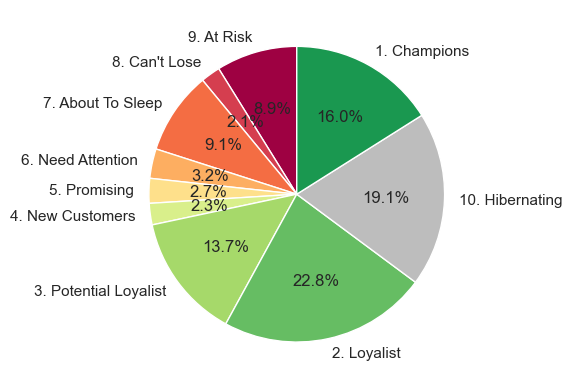

In [9]:
counts = classic_df['classic_cluster_name'].value_counts().sort_index(ascending=False)

plt.pie(
    counts,
    labels=counts.index,
    colors=[color_map[label] for label in counts.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.show()

In [10]:
classic_df['classic_cluster_name'].unique()

<ArrowStringArray>
[          '2. Loyalist',     '6. Need Attention',     '7. About To Sleep',
       '10. Hibernating',            '9. At Risk',          '1. Champions',
 '3. Potential Loyalist',      '4. New Customers',          '5. Promising',
         '8. Can't Lose']
Length: 10, dtype: str

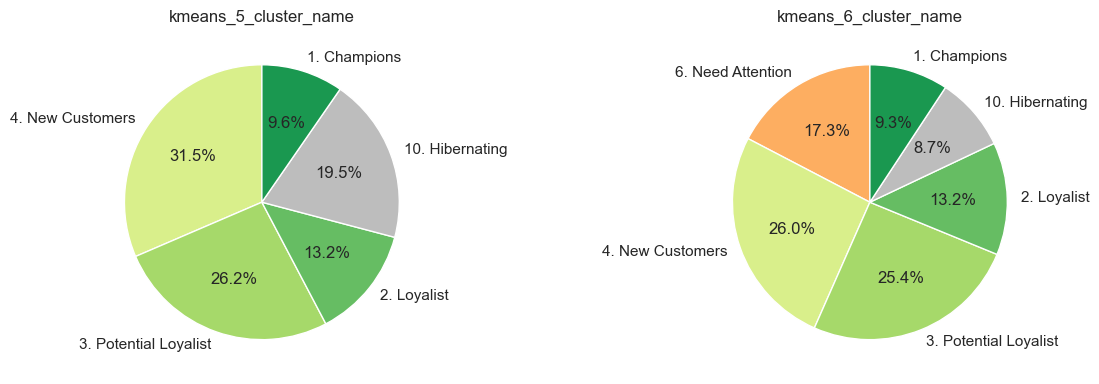

In [11]:
cols = ['kmeans_5_cluster_name', 'kmeans_6_cluster_name']

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, col in zip(axes, cols):
    counts = kmeans_df[col].value_counts().sort_index(ascending=False)
    colors = [color_map[i] for i in counts.index]

    ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)

plt.tight_layout()
plt.show()

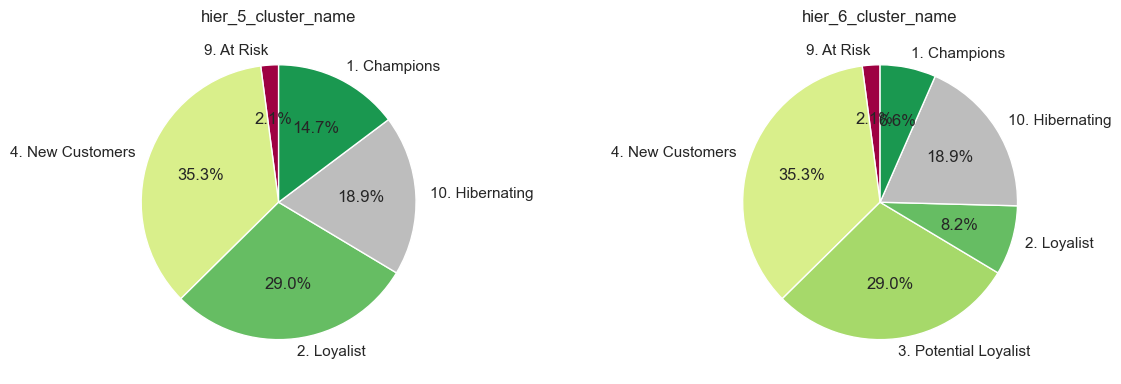

In [12]:
cols = ['hier_5_cluster_name', 'hier_6_cluster_name']

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, col in zip(axes, cols):
    counts = hier_df[col].value_counts().sort_index(ascending=False)
    colors = [color_map[i] for i in counts.index]

    ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [13]:
segments = list(color_map.keys())

segments_df = pd.DataFrame({
    'rfm_classic_segment': segments,
    
    'rfm_classic_segment_distribution': (
        classic_df['classic_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values * 100
    ),
    
    'kmeans_5_cluster_distribution': (
        kmeans_df['kmeans_5_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values * 100
    ),

    'kmeans_6_cluster_distribution': (
        kmeans_df['kmeans_6_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values * 100
    ),
    
    'hier_5_cluster_distribution': (
        hier_df['hier_5_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values *100
    ),

    'hier_6_cluster_distribution': (
        hier_df['hier_6_cluster_name']
        .value_counts(normalize=True)
        .reindex(segments, fill_value=0)
        .values *100
    )
})

segments_df = segments_df.round(1)
segments_df

,rfm_classic_segment,rfm_classic_segment_distribution,kmeans_5_cluster_distribution,kmeans_6_cluster_distribution,hier_5_cluster_distribution,hier_6_cluster_distribution
0,1. Champions,16.0,9.6,9.3,14.7,6.6
1,2. Loyalist,22.8,13.2,13.2,29.0,8.2
2,3. Potential Loyalist,13.7,26.2,25.4,0.0,29.0
3,4. New Customers,2.3,31.5,26.0,35.3,35.3
4,5. Promising,2.7,0.0,0.0,0.0,0.0
5,6. Need Attention,3.2,0.0,17.3,0.0,0.0
6,7. About To Sleep,9.1,0.0,0.0,0.0,0.0
7,8. Can't Lose,2.1,0.0,0.0,0.0,0.0
8,9. At Risk,8.9,0.0,0.0,2.1,2.1
9,10. Hibernating,19.1,19.5,8.7,18.9,18.9


> Increasing the number of clusters from 5 to 6 reveals additional behavioral sub-segments in different dimensions of the RFM space:
- Increase kmeans clusters count from 5 to 6 introduces the "Need Attention" sub group (a segmentation on Recency axis)

- Increase hier clusters count from 5 to 6 introduces the "Potential Loyalist" sub group (a segmentation on Value/Frequency axis)

--> Different clustering algorithms emphasize different behavioral dimensions.

> Hierachical methods introduces minor sub group "At Risk" at just 2% of the total customers --> depend on how significant this group is, this segmentation will become less attractive to the business teams

# 4. Analyze Recency distribution

In [14]:
# Select only needed columns
classic = classic_df[['household_key', 'recency', 'classic_cluster_name']].copy()
classic['method'] = 'classic'
classic.rename(columns={'classic_cluster_name': 'cluster'}, inplace=True)

kmeans5 = kmeans_df[['household_key', 'recency', 'kmeans_5_cluster_name']].copy()
kmeans5['method'] = 'kmeans_5'
kmeans5.rename(columns={'kmeans_5_cluster_name': 'cluster'}, inplace=True)

kmeans6 = kmeans_df[['household_key', 'recency', 'kmeans_6_cluster_name']].copy()
kmeans6['method'] = 'kmeans_6'
kmeans6.rename(columns={'kmeans_6_cluster_name': 'cluster'}, inplace=True)

hier5 = hier_df[['household_key', 'recency', 'hier_5_cluster_name']].copy()
hier5['method'] = 'hier_5'
hier5.rename(columns={'hier_5_cluster_name': 'cluster'}, inplace=True)

hier6 = hier_df[['household_key', 'recency', 'hier_6_cluster_name']].copy()
hier6['method'] = 'hier_6'
hier6.rename(columns={'hier_6_cluster_name': 'cluster'}, inplace=True)

# Combine all
recency_df = pd.concat([classic, kmeans5, kmeans6, hier5, hier6], ignore_index=True)

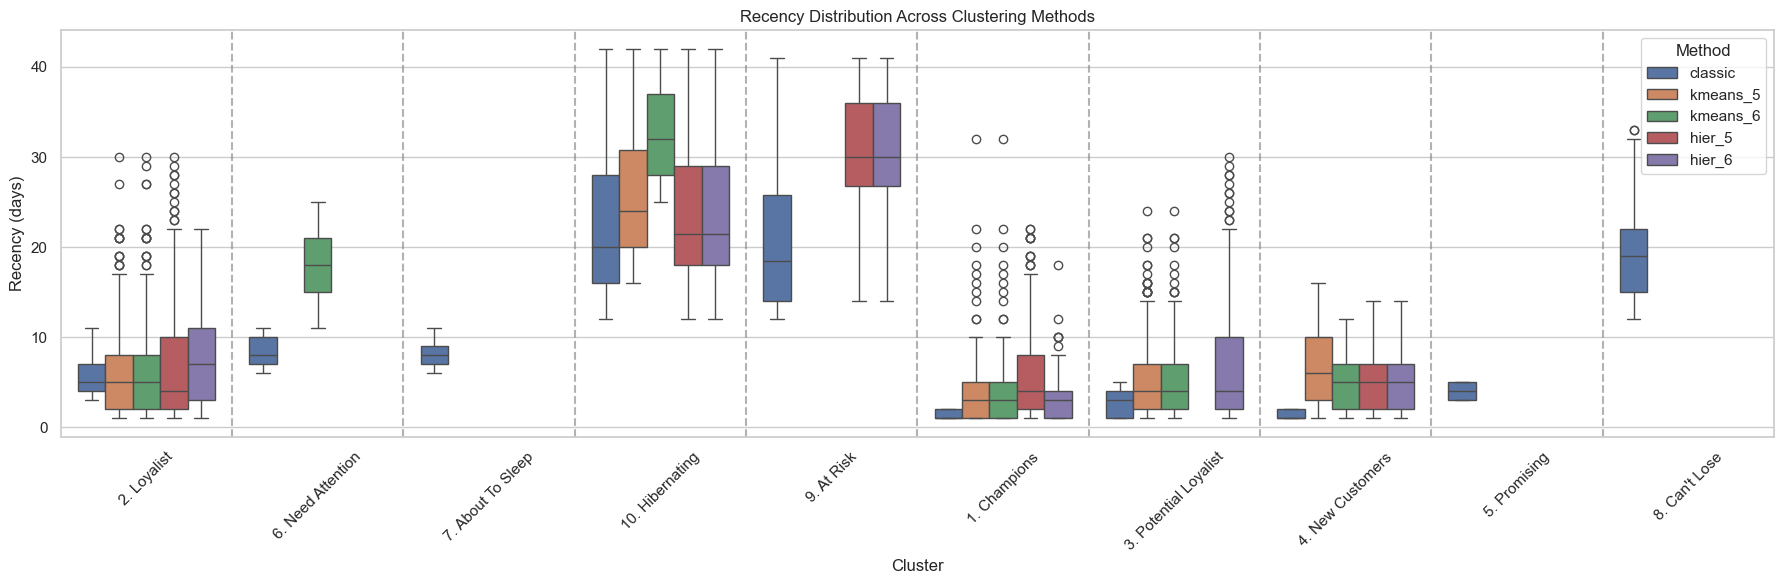

In [15]:
plt.figure(figsize=(18,6))

ax = sns.boxplot(
    data=recency_df,
    x='cluster',
    y='recency',
    hue='method'
)

# Add vertical dividers between clusters
clusters = recency_df['cluster'].unique()
for i in range(len(clusters) - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.title("Recency Distribution Across Clustering Methods")
plt.xlabel("Cluster")
plt.ylabel("Recency (days)")
plt.legend(title="Method")

plt.tight_layout()
plt.show()


> The clusters Loyalist, Champions, Potential Loyalist, and New Customers show similar recency distributions across methods. This indicates that these customer groups are stable segments, meaning that regardless of the segmentation technique (classic RFM, K-Means, or hierarchical clustering), customers with similar purchase recency are grouped consistently.

--> Recency strongly drives these behavioral segments, so both rule-based and unsupervised clustering detect them reliably.

> KMeans = 6 produces a tighter distribution for the "Hibernating" group 

--> Increasing the number of clusters allowed K-Means to isolate a more homogeneous inactive-customer segment.

# 5. Analyze Frequency distribution

In [16]:
# Select only needed columns
classic = classic_df[['household_key', 'frequency', 'classic_cluster_name']].copy()
classic['method'] = 'classic'
classic.rename(columns={'classic_cluster_name': 'cluster'}, inplace=True)

kmeans5 = kmeans_df[['household_key', 'frequency', 'kmeans_5_cluster_name']].copy()
kmeans5['method'] = 'kmeans_5'
kmeans5.rename(columns={'kmeans_5_cluster_name': 'cluster'}, inplace=True)

kmeans6 = kmeans_df[['household_key', 'frequency', 'kmeans_6_cluster_name']].copy()
kmeans6['method'] = 'kmeans_6'
kmeans6.rename(columns={'kmeans_6_cluster_name': 'cluster'}, inplace=True)

hier5 = hier_df[['household_key', 'frequency', 'hier_5_cluster_name']].copy()
hier5['method'] = 'hier_5'
hier5.rename(columns={'hier_5_cluster_name': 'cluster'}, inplace=True)

hier6 = hier_df[['household_key', 'frequency', 'hier_6_cluster_name']].copy()
hier6['method'] = 'hier_6'
hier6.rename(columns={'hier_6_cluster_name': 'cluster'}, inplace=True)

# Combine all
frequency_df = pd.concat([classic, kmeans5, kmeans6, hier5, hier6], ignore_index=True)

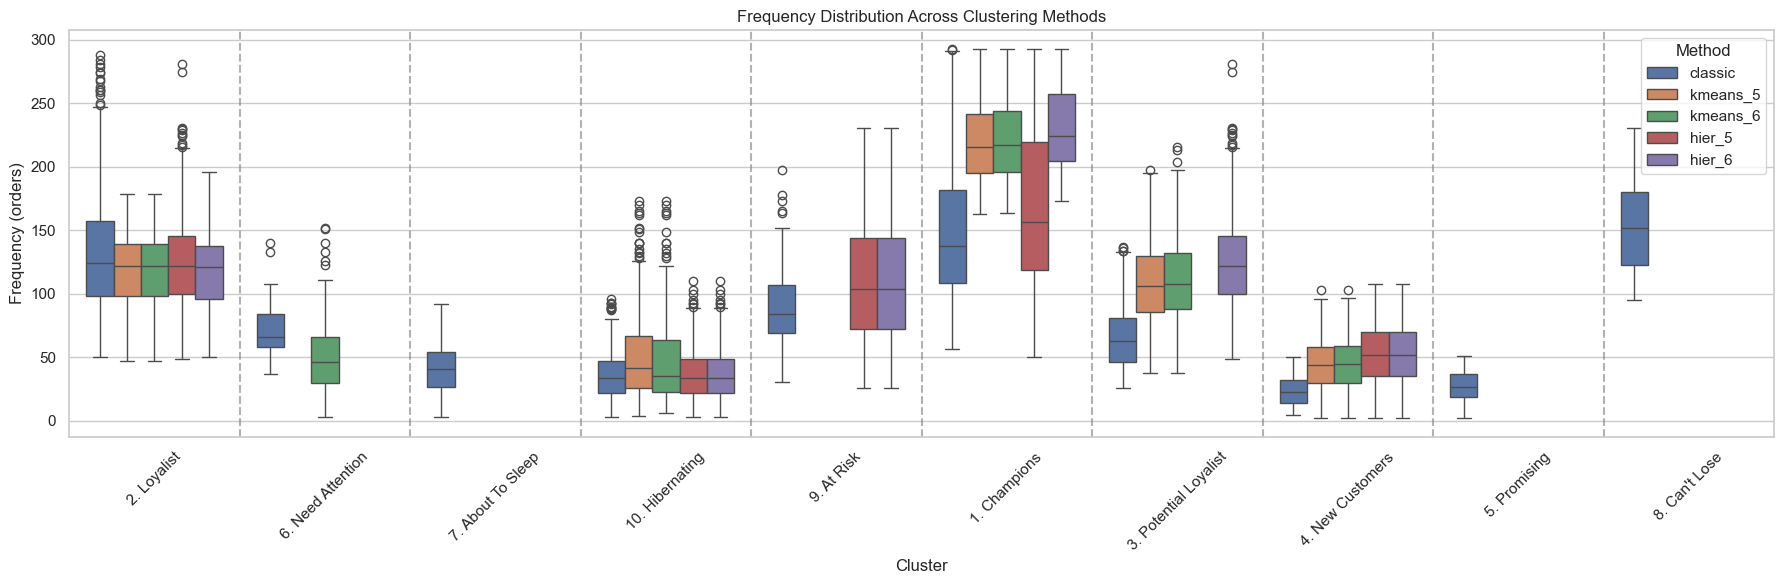

In [17]:
plt.figure(figsize=(18,6))

ax = sns.boxplot(
    data=frequency_df,
    x='cluster',
    y='frequency',
    hue='method'
)

# Add vertical dividers between clusters
clusters = frequency_df['cluster'].unique()
for i in range(len(clusters) - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.title("Frequency Distribution Across Clustering Methods")
plt.xlabel("Cluster")
plt.ylabel("Frequency (orders)")
plt.legend(title="Method")

plt.tight_layout()
plt.show()

> The clusters Loyalist, New Customers, and Hibernating show similar frequency distributions across segmentation methods.

--> Customers in these groups tend to have relatively comparable purchase counts, allowing different segmentation approaches to identify these segments consistently.

> The Champions and Loyalist segments produced by Classic RFM and Hierarchical (k=6) show a broader frequency distribution.

--> These methods allow greater variability in purchase frequency within the same segment. Rather than indicating that Frequency is not an important feature, the broader spread likely reflects that these segmentation approaches rely on combined RFM characteristics and may not strictly minimize within-cluster variance for Frequency, resulting in more heterogeneous clusters.

# 6. Analyze Monetary distribution

In [18]:
# Select only needed columns
classic = classic_df[['household_key', 'monetary', 'classic_cluster_name']].copy()
classic['method'] = 'classic'
classic.rename(columns={'classic_cluster_name': 'cluster'}, inplace=True)

kmeans5 = kmeans_df[['household_key', 'monetary', 'kmeans_5_cluster_name']].copy()
kmeans5['method'] = 'kmeans_5'
kmeans5.rename(columns={'kmeans_5_cluster_name': 'cluster'}, inplace=True)

kmeans6 = kmeans_df[['household_key', 'monetary', 'kmeans_6_cluster_name']].copy()
kmeans6['method'] = 'kmeans_6'
kmeans6.rename(columns={'kmeans_6_cluster_name': 'cluster'}, inplace=True)

hier5 = hier_df[['household_key', 'monetary', 'hier_5_cluster_name']].copy()
hier5['method'] = 'hier_5'
hier5.rename(columns={'hier_5_cluster_name': 'cluster'}, inplace=True)

hier6 = hier_df[['household_key', 'monetary', 'hier_6_cluster_name']].copy()
hier6['method'] = 'hier_6'
hier6.rename(columns={'hier_6_cluster_name': 'cluster'}, inplace=True)

# Combine all
monetary_df = pd.concat([classic, kmeans5, kmeans6, hier5, hier6], ignore_index=True)

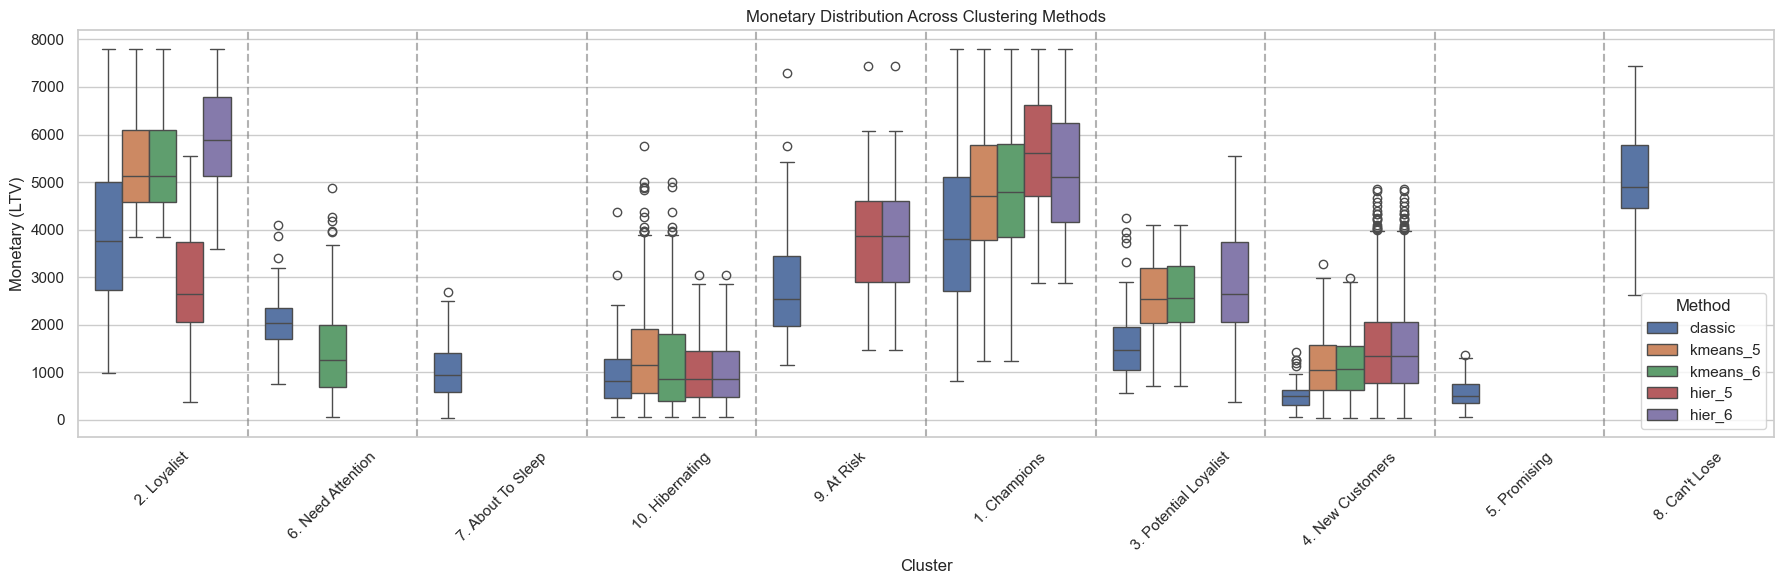

In [19]:
plt.figure(figsize=(18,6))

ax = sns.boxplot(
    data=monetary_df,
    x='cluster',
    y='monetary',
    hue='method'
)

# Add vertical dividers between clusters
clusters = monetary_df['cluster'].unique()
for i in range(len(clusters) - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.title("Monetary Distribution Across Clustering Methods")
plt.xlabel("Cluster")
plt.ylabel("Monetary (LTV)")
plt.legend(title="Method")

plt.tight_layout()
plt.show()

> KMeans (k=5 and k=6) show relatively tight distributions, indicating that high-value customers are grouped into a more homogeneous cluster

> Hierarchical k=5 and Classic RFM shows a slightly wider spread, suggesting greater variability in customer spending within the Champions and Loyalist segment

> Both Hierachical clusters show broader spread on New Customers segment, while both Kmeans cluster show broader spread on Hibernating segment --> There are trade off between clustering methods.

--> Overall, the K-Means approach produces the most compact and clearly separated segments in terms of monetary value, suggesting that it is more effective at grouping customers with similar spending profiles.

# 7. Clusters Structure

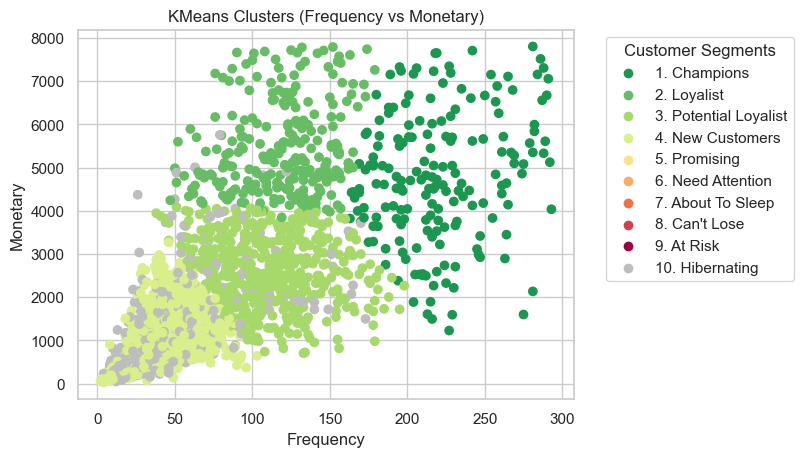

In [20]:
# Convert cluster name to color
colors = kmeans_df['kmeans_5_cluster_name'].map(color_map)

plt.scatter(
    kmeans_df['frequency'],
    kmeans_df['monetary'],
    c=colors
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('KMeans Clusters (Frequency vs Monetary)')

# Create legend manually
for cluster, color in color_map.items():
    plt.scatter([], [], c=color, label=cluster)

plt.legend(title="Customer Segments", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# 8. Evaluate Clusters Internal Metrics

In [27]:
combined_df = pd.concat(
    [
        classic_df,
        kmeans_df[['kmeans_5_cluster_id', 'kmeans_6_cluster_id']],
        hier_df[['hier_5_cluster_id', 'hier_6_cluster_id']]
    ],
    axis=1
)
combined_df.head()

,household_key,recency,frequency,monetary,classic_cluster_name,kmeans_5_cluster_id,kmeans_6_cluster_id,hier_5_cluster_id,hier_6_cluster_id
0,1,6,86,4330.16,2. Loyalist,1,1,0,0
1,3,9,46,2519.75,6. Need Attention,2,2,0,0
2,5,9,39,757.07,7. About To Sleep,2,2,0,0
3,6,5,242,5613.98,2. Loyalist,0,0,1,1
4,7,3,59,3350.77,2. Loyalist,4,4,0,0


In [23]:
# Instantiate
scaler = StandardScaler()

# Fit_transform
rfm_df_scaled = scaler.fit_transform(combined_df[['recency', 'frequency', 'monetary']])
rfm_df_scaled

array([[-0.38288671, -0.05261494,  1.01279346],
       [-0.06642417, -0.71831957,  0.02102064],
       [-0.06642417, -0.83481788, -0.94460489],
       ...,
       [-0.80483676,  1.32872218,  0.02764374],
       [-0.69934924, -0.13582802,  0.25402351],
       [-0.59386173,  0.18038169,  1.08492449]], shape=(1920, 3))

In [24]:
# Convert to dataframe
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['recency', 'frequency', 'monetary']
rfm_df_scaled.head()

,recency,frequency,monetary
0,-0.382887,-0.052615,1.012793
1,-0.066424,-0.718320,0.021021
2,-0.066424,-0.834818,-0.944605
3,-0.488374,2.543633,1.716091
4,-0.699349,-0.501966,0.476267


In [30]:
results = []

for col in [
    'kmeans_5_cluster_id',
    'kmeans_6_cluster_id',
    'hier_5_cluster_id',
    'hier_6_cluster_id'
]:
    labels = combined_df[col]

    results.append({
        "model": col,
        "n_clusters": len(set(labels)),
        "silhouette_score": silhouette_score(rfm_df_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(rfm_df_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(rfm_df_scaled, labels)
    })

metrics_df = pd.DataFrame(results)
metrics_df.sort_values(by="silhouette_score", ascending=False).round(3)

,model,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,kmeans_5_cluster_id,5,0.328,1364.068,0.999
1,kmeans_6_cluster_id,6,0.325,1332.279,1.024
3,hier_6_cluster_id,6,0.286,905.888,1.072
2,hier_5_cluster_id,5,0.275,915.339,1.189


> Evaluation results clearly show K-Means Clustering outperforming Hierarchical Clustering for this RFM segmentation:
- Highest Silhouette Score → clusters are better separated
- Highest Calinski-Harabasz → strong between-cluster variance
- Lowest Davies-Bouldin → clusters are compact and distinct

> The difference between K-Means Clustering with k=5 and k=6 in evaluation metrics is very small:
- Silhouette difference: 0.0025 → extremely small
- Calinski-Harabasz: small drop
- Davies-Bouldin: slightly worse but still close\

--> In clustering practice, differences this small usually mean the additional cluster doesn't strongly change the structure of the data.

✅ Both models are statistically acceptable

✅ Business interpretability should determine the final choice

# 9. Decide between KMeans 5 & 6

In [43]:
k5_profile = (
    kmeans_df
    .groupby("kmeans_5_cluster_name")
    .agg(
        recency=("recency","mean"),
        frequency=("frequency","mean"),
        monetary=("monetary","mean"),
        count=("recency","size")
    )
)

k6_profile = (
    kmeans_df
    .groupby("kmeans_6_cluster_name")
    .agg(
        recency=("recency","mean"),
        frequency=("frequency","mean"),
        monetary=("monetary","mean"),
        count=("recency","size")
    )
)

In [44]:
print(k5_profile)
print(k6_profile)

                         recency   frequency     monetary  count
kmeans_5_cluster_name                                           
1. Champions            3.924324  220.048649  4774.453351    185
10. Hibernating        25.727273   49.863636  1379.981070    374
2. Loyalist             6.110672  118.462451  5427.854269    253
3. Potential Loyalist   5.091270  109.390873  2588.559385    504
4. New Customers        6.670530   44.251656  1137.381705    604
                         recency   frequency     monetary  count
kmeans_6_cluster_name                                           
1. Champions            4.005618  221.112360  4865.462978    178
10. Hibernating        32.520958   48.562874  1254.100479    167
2. Loyalist             6.236220  118.460630  5431.701535    254
3. Potential Loyalist   4.827869  111.817623  2603.974160    488
4. New Customers        4.936000   44.826000  1136.880920    500
6. Need Attention      17.828829   50.009009  1411.192703    333


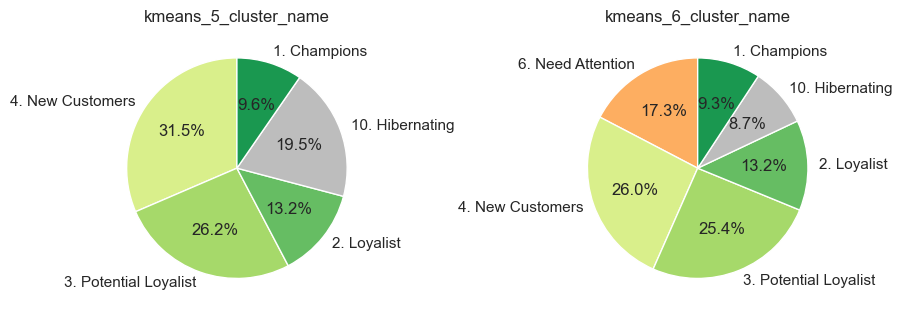

In [42]:
cols = ['kmeans_5_cluster_name', 'kmeans_6_cluster_name']

fig, axes = plt.subplots(1, 2, figsize=(9,4))

for ax, col in zip(axes, cols):
    counts = kmeans_df[col].value_counts().sort_index(ascending=False)
    colors = [color_map[i] for i in counts.index]

    ax.pie(counts, labels=counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(col)

plt.tight_layout()
plt.show()

> The extra cluster in k=6 is “Need Attention”, which is essentially splitting the old “Hibernating” group:
- Need Attention
    + moderate recency
    + still recoverable
    + early churn risk

- Hibernating
    + very old last purchase
    + already disengaged
    + harder to reactivate

> K=6 introduces a meaningful lifecycle stage:
- Need Attention : win-back campaigns, reminders
- Hibernating : heavy discount / reactivation


KMeans k=5 loses the ability to separate recoverable vs lost customers --> meaningful improvement for CRM strategy.

# 10. Final Recommendation

| Model | Data Characteristics | Business Interpretation |
| --- | --- | --- |
| Classic RFM | Broad profiles from quantile scoring | Many small segments; hard to target |
| KMeans (k=5) | Best metrics; compact profiles | Clear segments but limited lifecycle detail |
| **KMeans (k=6)** | **Slightly worse metrics; compact profiles** | Adds meaningful “Need Attention” segment |
| Hierachical (k=5) | Broader profiles; weaker metrics | Tiny segment with low impact |
| Hierachical (k=6) | Compact profiles but worst metrics | Tiny segment with low impact |

> Pick KMeans (k=6) at the final RFM Segmentation appproach.